# 📊 E-Commerce Customer Analysis

## 📌 Project Overview
# This markdown cell introduces the project's focus on e-commerce data analysis
# The analysis will examine three key areas:
# 1. Sales trends - to understand revenue patterns over time
# 2. Customer behavior - to identify purchasing patterns and preferences
# 3. Profitability insights - to determine which products/customers drive profit
# The ultimate purpose is to provide actionable insights for business decisions


## 🎯 Business Problem
# This section defines the core business challenge being addressed
# E-commerce companies collect extensive transaction data
# The challenge is extracting meaningful insights from this raw data
# Without proper analysis, businesses cannot identify:
#   - Profitable customer segments
#   - High-performing products
#   - Emerging market trends
E-commerce businesses generate large volumes of transactional data,
but without analysis it is difficult to identify profitable segments,
products, and trends.

In [18]:
import pandas as pd
import plotly.express as px # Data visualization library
import plotly.graph_objects as go # Graphical visuals
import plotly.io as pio  # Graph template
import plotly.colors as colors
pio.templates.default="plotly_white"

data=pd.read_csv('superstore.csv',encoding= 'latin- 1')
data.head()

## 📂 Dataset Overview
The dataset contains order-level e-commerce data including sales,
profit, category, sub-category, customer segment, and order date.


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quanti

In [7]:
data['Order Date']=pd.to_datetime(data['Order Date'])
data['Ship Date']=pd.to_datetime(data['Ship Date'])

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         10800 non-null  object        
 1   Order ID       10800 non-null  object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994

In [10]:
data['Order Month']=data['Order Date'].dt.month
data['Order Year']= data['Order Date'].dt.year
data['Order by Week']= data['Order Date'].dt.dayofweek

In [11]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order by Week
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,11.0,2017.0,2.0
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,11.0,2017.0,2.0
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,6.0,2017.0,0.0
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,10.0,2016.0,1.0
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,10.0,2016.0,1.0


In [13]:
data['Order Month'] = data['Order Month'].astype('Int64')
data['Order Year'] = data['Order Year'].astype('Int64')
data['Order by Week'] = data['Order by Week'].astype('Int64')


In [14]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order by Week
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,11,2017,2
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,11,2017,2
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,6,2017,0
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,10,2016,1
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,10,2016,1


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         10800 non-null  object        
 1   Order ID       10800 non-null  object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994

## 🔍 Exploratory Data Analysis (EDA)
Exploratory analysis is performed to identify patterns and trends in
sales, profit, and customer behavior.


In [16]:
sales_by_month = data.groupby('Order Month')['Sales'].sum().reset_index()
sales_by_month

,Order Month,Sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


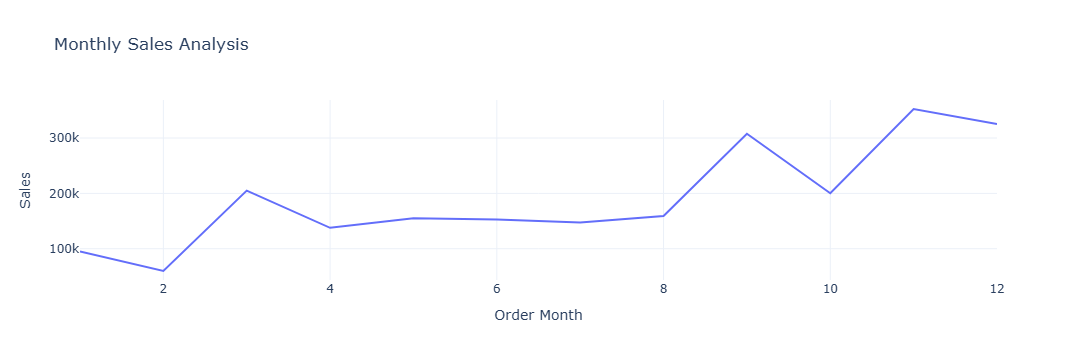

In [20]:
fig=px.line(sales_by_month,
           x='Order Month',
           y='Sales',
           title='Monthly Sales Analysis')
fig.show()

In [21]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order by Week
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,11,2017,2
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,11,2017,2
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,6,2017,0
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,10,2016,1
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,10,2016,1


### 📌 Sales by Category
This analysis compares total sales across different product categories.


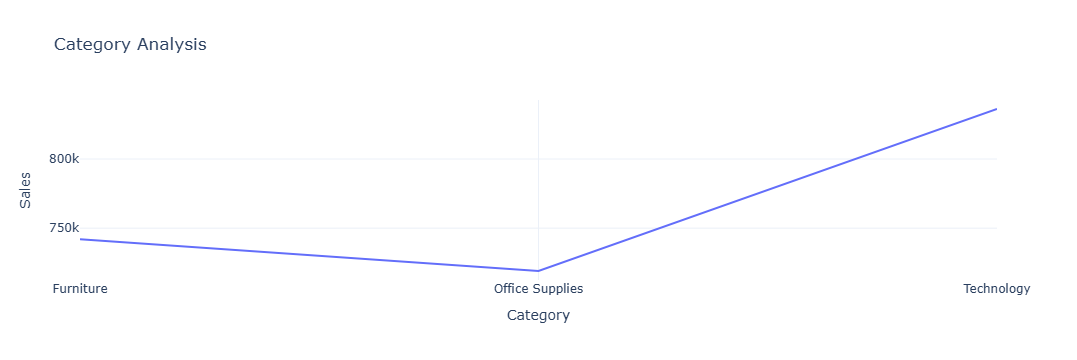

In [22]:
sales_by_category= data.groupby('Category')['Sales'].sum().reset_index()
fig=px.line(sales_by_category,
            x= 'Category',
            y= 'Sales',
            title= 'Category Analysis')
fig.show()

**Insight:**  
Technology and Office Supplies categories contribute the highest sales,
indicating strong demand in these segments.


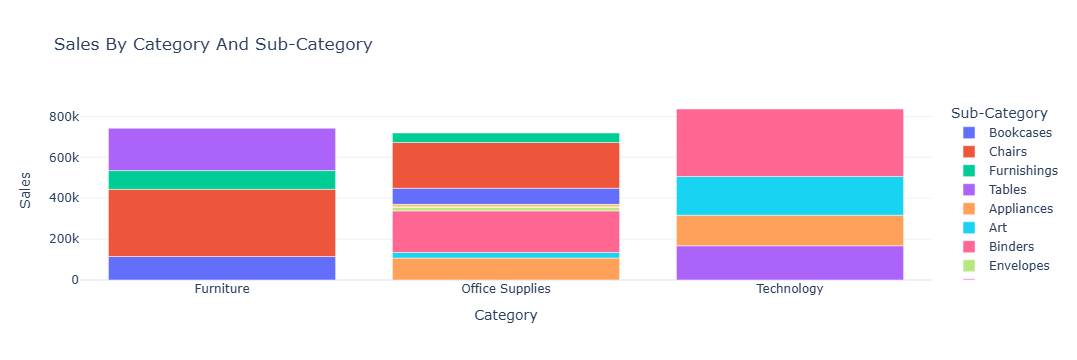

In [29]:
sales_by_sub_category= (data.groupby(['Category','Sub-Category'])['Sales'].sum().reset_index())
fig=px.bar(sales_by_sub_category,
          x= 'Category',
          y= 'Sales',
          color= 'Sub-Category',
          title= 'Sales By Category And Sub-Category')
fig.show()

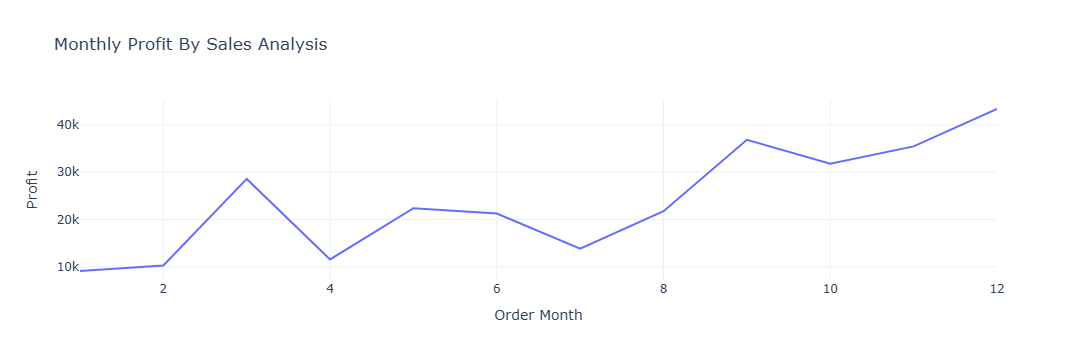

In [31]:
monthly_profit_0f_sales= data.groupby('Order Month')['Profit'].sum().reset_index()
fig=px.line(monthly_profit_0f_sales,
           x= 'Order Month',
           y= 'Profit',
           title= 'Monthly Profit By Sales Analysis')
fig.show()

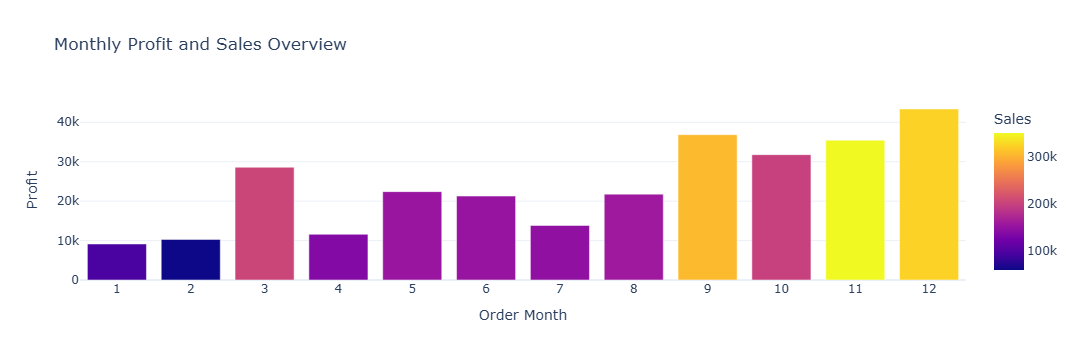

In [38]:
monthly_profit_sales= data.groupby('Order Month')[['Sales','Profit']].sum().reset_index()
fig=px.bar(monthly_profit_sales,
           x= 'Order Month',
           y= 'Profit',
           color= 'Sales',
           title= 'Monthly Profit and Sales Overview')
fig.update_xaxes(
    tickmode='linear',
    tick0= 1,
    dtick= 1
)
fig.show()

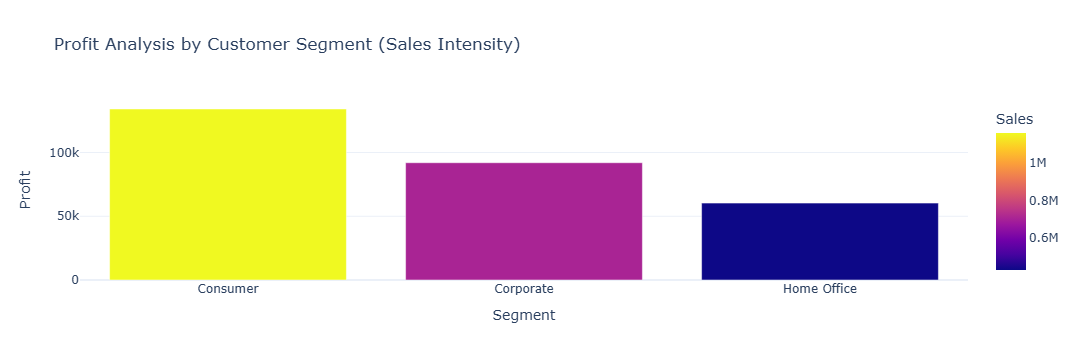

In [49]:
sales_profit_segm= data.groupby('Segment')[['Sales','Profit']].sum().reset_index()
fig=px.bar(sales_profit_segm,
          x= 'Segment',
          y= 'Profit',
          color= 'Sales',
          title= 'Profit Analysis by Customer Segment (Sales Intensity)')
fig.show()

In [52]:
sales_profit_segment = data.groupby('Segment').agg({'Sales': 'sum' , 'Profit': 'sum'}).reset_index()
sales_profit_segment['Sales_to_profit_Ratio']=sales_profit_segment['Sales']/sales_profit_segment['Profit']
sales_profit_segment[['Segment','Sales_to_profit_Ratio']]

,Segment,Sales_to_profit_Ratio
0,Consumer,8.659471
1,Corporate,7.677245
2,Home Office,7.125416


## 📈 Key Insights
- Consumer segment generates the highest profit
- Some sub-categories show negative profit despite high sales
- Profitability varies significantly across months


## 💡 Business Recommendations
- Focus marketing on high-profit customer segments
- Optimize discounts for loss-making products
- Improve inventory planning based on monthly trends


## ✅ Conclusion
This analysis provides actionable insights into customer behavior,
product performance, and profitability, enabling data-driven
decision-making for e-commerce businesses.
